K: 1
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Training Time: 0.011286497116088867
Prediction Time: 0.005072355270385742

K: 3
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Training Time: 0.003349781036376953
Prediction Time: 0.007766246795654297

K: 5
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Training Time: 0.004772663116455078
Prediction Time: 0.005740642547607422

K: 7
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Training Time: 0.0011551380157470703
Prediction Time: 0.006758451461791992

K: 9
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Training Time: 0.003283262252807617
Prediction Time: 0.004504203796386719

Manhattan Accuracy: 1.0


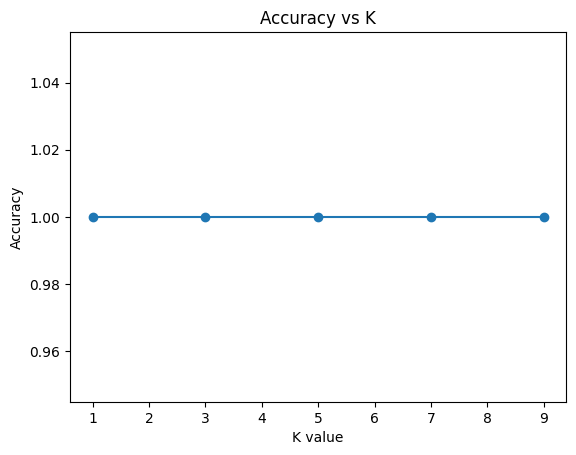

Multinomial NB Accuracy: 0.5
Probability Output:
 [[0.53057829 0.46942171]
 [0.53057829 0.46942171]]
Gaussian NB Accuracy: 0.9777777777777777
Probability Output:
 [[4.15880005e-088 9.95527834e-001 4.47216606e-003]
 [1.00000000e+000 1.31031235e-013 2.21772205e-020]
 [9.83170191e-285 2.70138564e-012 1.00000000e+000]
 [9.54745274e-092 9.74861431e-001 2.51385686e-002]
 [1.08679560e-103 8.31910700e-001 1.68089300e-001]]

Comparison
KNN Accuracy: 1.0
Naive Bayes Accuracy: 0.9777777777777777
KNN Precision: 1.0
NB Precision: 0.9761904761904763
KNN Recall: 1.0
NB Recall: 0.9743589743589745


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

# ---------------------------------------
# PART A – KNN IMPLEMENTATION
# ---------------------------------------

iris = load_iris()
X = iris.data
y = iris.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

k_values=[1,3,5,7,9]
accuracy_list=[]

for k in k_values:

    knn=KNeighborsClassifier(n_neighbors=k,metric='euclidean')

    start=time.time()
    knn.fit(X_train,y_train)
    train_time=time.time()-start

    start=time.time()
    pred=knn.predict(X_test)
    predict_time=time.time()-start

    acc=accuracy_score(y_test,pred)
    accuracy_list.append(acc)

    print("K:",k)
    print("Accuracy:",acc)
    print("Precision:",precision_score(y_test,pred,average='macro'))
    print("Recall:",recall_score(y_test,pred,average='macro'))
    print("Training Time:",train_time)
    print("Prediction Time:",predict_time)
    print()

# Manhattan Distance
knn_manhattan=KNeighborsClassifier(n_neighbors=5,metric='manhattan')
knn_manhattan.fit(X_train,y_train)
pred_manhattan=knn_manhattan.predict(X_test)

print("Manhattan Accuracy:",accuracy_score(y_test,pred_manhattan))

# Plot Accuracy vs K
plt.plot(k_values,accuracy_list,marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()


# ---------------------------------------
# PART B – NAIVE BAYES IMPLEMENTATION
# ---------------------------------------

# Sample SMS Spam dataset
sms_data = pd.DataFrame({
'text':[
"Win money now",
"Call me later",
"Free lottery ticket",
"Let's meet tomorrow",
"Congratulations you won prize",
"How are you"
],
'label':[1,0,1,0,1,0]   # 1 = spam , 0 = ham
})

vectorizer=CountVectorizer()

X_text=vectorizer.fit_transform(sms_data['text'])
y_text=sms_data['label']

X_train_text,X_test_text,y_train_text,y_test_text = train_test_split(X_text,y_text,test_size=0.3,random_state=42)

# Multinomial Naive Bayes
mnb=MultinomialNB(alpha=1)

mnb.fit(X_train_text,y_train_text)

pred_text=mnb.predict(X_test_text)

print("Multinomial NB Accuracy:",accuracy_score(y_test_text,pred_text))

print("Probability Output:\n",mnb.predict_proba(X_test_text))


# Gaussian Naive Bayes on Iris Data
gnb=GaussianNB()

gnb.fit(X_train,y_train)

pred_gnb=gnb.predict(X_test)

print("Gaussian NB Accuracy:",accuracy_score(y_test,pred_gnb))

print("Probability Output:\n",gnb.predict_proba(X_test)[:5])


# ---------------------------------------
# PART C – COMPARISON
# ---------------------------------------

print("\nComparison")

print("KNN Accuracy:",accuracy_score(y_test,knn.predict(X_test)))
print("Naive Bayes Accuracy:",accuracy_score(y_test,pred_gnb))

print("KNN Precision:",precision_score(y_test,knn.predict(X_test),average='macro'))
print("NB Precision:",precision_score(y_test,pred_gnb,average='macro'))

print("KNN Recall:",recall_score(y_test,knn.predict(X_test),average='macro'))
print("NB Recall:",recall_score(y_test,pred_gnb,average='macro'))
